# Import Necessary Libraries

In [1]:
import os
import zipfile
from sklearn.model_selection import train_test_split
import shutil
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# Unzip the Dataset and splitting it in 3 part - train(70%) , test(10%)  , valid(20%)



In [3]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

# Step 1: Unzip the dataset
dataset_zip_path = '/content/gdrive/MyDrive/preprocessed_dataset.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print("Dataset extracted successfully.")

# Step 2: Define directories
train_dir = os.path.join(extract_path, 'train')
val_dir = os.path.join(extract_path, 'val')
test_dir = os.path.join(extract_path, 'test')  # Create a new test directory

os.makedirs(test_dir, exist_ok=True)

# Split validation data into validation (20%) and test (10%)
for class_name in os.listdir(val_dir):
    class_path = os.path.join(val_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        val_images, test_images = train_test_split(images, test_size=1/3, random_state=42)

        # Create class-specific subdirectories in test_dir
        test_class_dir = os.path.join(test_dir, class_name)
        os.makedirs(test_class_dir, exist_ok=True)

        # Move test images to the test directory
        for img in test_images:
            shutil.move(os.path.join(class_path, img), os.path.join(test_class_dir, img))

print("Validation data split into validation and test sets successfully.")

Mounted at /content/gdrive
Dataset extracted successfully.
Validation data split into validation and test sets successfully.


# Data Preprocessing and Augmentation

In [4]:
# Data preprocessing and augmentation
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 43444 images belonging to 38 classes.
Found 7229 images belonging to 38 classes.
Found 3632 images belonging to 38 classes.


# Defining and Training the Model

In [5]:
# Define the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
checkpoint_callback = ModelCheckpoint(
    filepath='/content/checkpoints/plant_disease_weights.{epoch:02d}-{val_accuracy:.2f}.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)


# Training the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    batch_size=batch_size,
    callbacks=[checkpoint_callback, early_stopping_callback,reduce_lr_callback]
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          19,494 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,415,590 (169.43 MB)

 Trainable params: 44,415,590 (169.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.3747 - loss: 2.3495
Epoch 1: val_accuracy improved from -inf to 0.75335, saving model to /content/checkpoints/plant_disease_weights.01-0.75.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 581s 420ms/step - accuracy: 0.3748 - loss: 2.3490 - val_accuracy: 0.7534 - val_loss: 0.8174 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.7353 - loss: 0.8482
Epoch 2: val_accuracy improved from 0.75335 to 0.81394, saving model to /content/checkpoints/plant_disease_weights.02-0.81.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 552s 405ms/step - accuracy: 0.7353 - loss: 0.8481 - val_accuracy: 0.8139 - val_loss: 0.6055 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.8166 - loss: 0.5773
Epoch 3: val_accuracy improved from 0.81394 to 0.86056, saving model to /content/checkpoints/plant_disease_weights.03-0.86.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 558s 402ms/step - accuracy: 0.81

# Saving Final Model

In [24]:
# Save Final Model
model.save('/content/gdrive/MyDrive/cnn_model.h5')
print("Model saved to Google Drive.")

Model saved to Google Drive.


# Accuaracy and Loss Plots

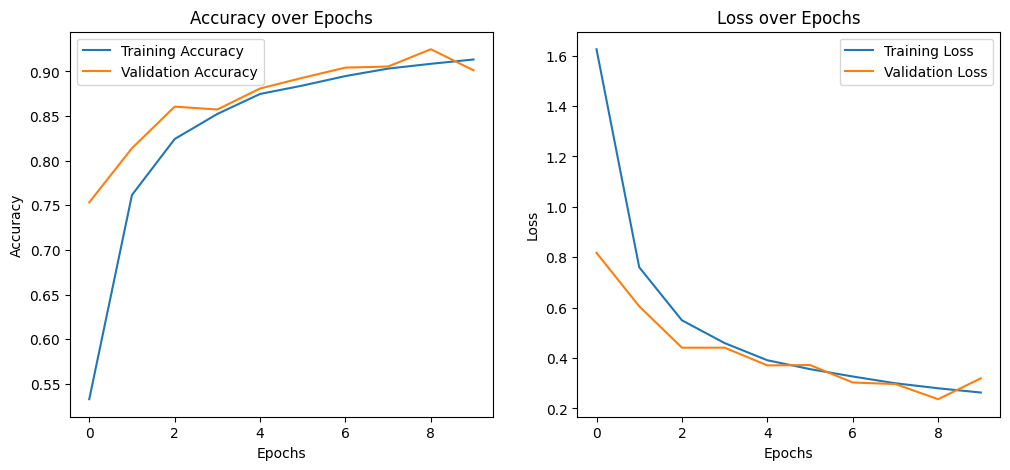

In [20]:
# Plot metrics
def plot_metrics(history):
    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    plt.show()

plot_metrics(history)

# Evaluating the Model and Classification Report

In [7]:
# Evaluate the model
results = model.evaluate(test_data)
print(f"Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}")

from sklearn.metrics import classification_report
# Performance Metrics
y_true = test_data.classes
y_pred = model.predict(test_data)
y_pred_classes = y_pred.argmax(axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=test_data.class_indices.keys()))

114/114 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.9288 - loss: 0.2194
Test Loss: 0.2518, Test Accuracy: 0.9210
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.87      0.79      0.82        42
                                 Apple___Black_rot       0.85      0.98      0.91        42
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        19
                                   Apple___healthy       0.93      0.93      0.93       110
                               Blueberry___healthy       0.94      0.95      0.95       100
          Cherry_(including_sour)___Powdery_mildew       1.00      0.94      0.97        70
                 Cherry_(including_sour)___healthy       0.77      0.98      0.86        57
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.54      0.

# Model Evaluation with Precision, Recall, and F1-Score Metrics

In [18]:
from sklearn import metrics
import numpy as np

# Evaluate the model
test_loss, test_acc = model.evaluate(test_data)

# Extract true labels and ensure proper format
true_labels = np.array(test_data.labels)

# Get predictions and convert to class indices
predicted_probabilities = model.predict(test_data)
predicted_labels = np.argmax(predicted_probabilities, axis=1)

# Calculate metrics
test_prec = metrics.precision_score(true_labels, predicted_labels, average='weighted')
test_rec = metrics.recall_score(true_labels, predicted_labels, average='weighted')
test_f1 = metrics.f1_score(true_labels, predicted_labels, average='weighted')

# Print metrics
print(f'Test Loss: {test_loss:.2f}')
print(f'Test Accuracy: {test_acc:.2f}')
print(f'Test Precision: {test_prec:.2f}')
print(f'Test Recall: {test_rec:.2f}')
print(f'Test F1-score: {test_f1:.2f}')


114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9288 - loss: 0.2194
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
Test Loss: 0.25
Test Accuracy: 0.92
Test Precision: 0.92
Test Recall: 0.92
Test F1-score: 0.92


# Confusion Matrix

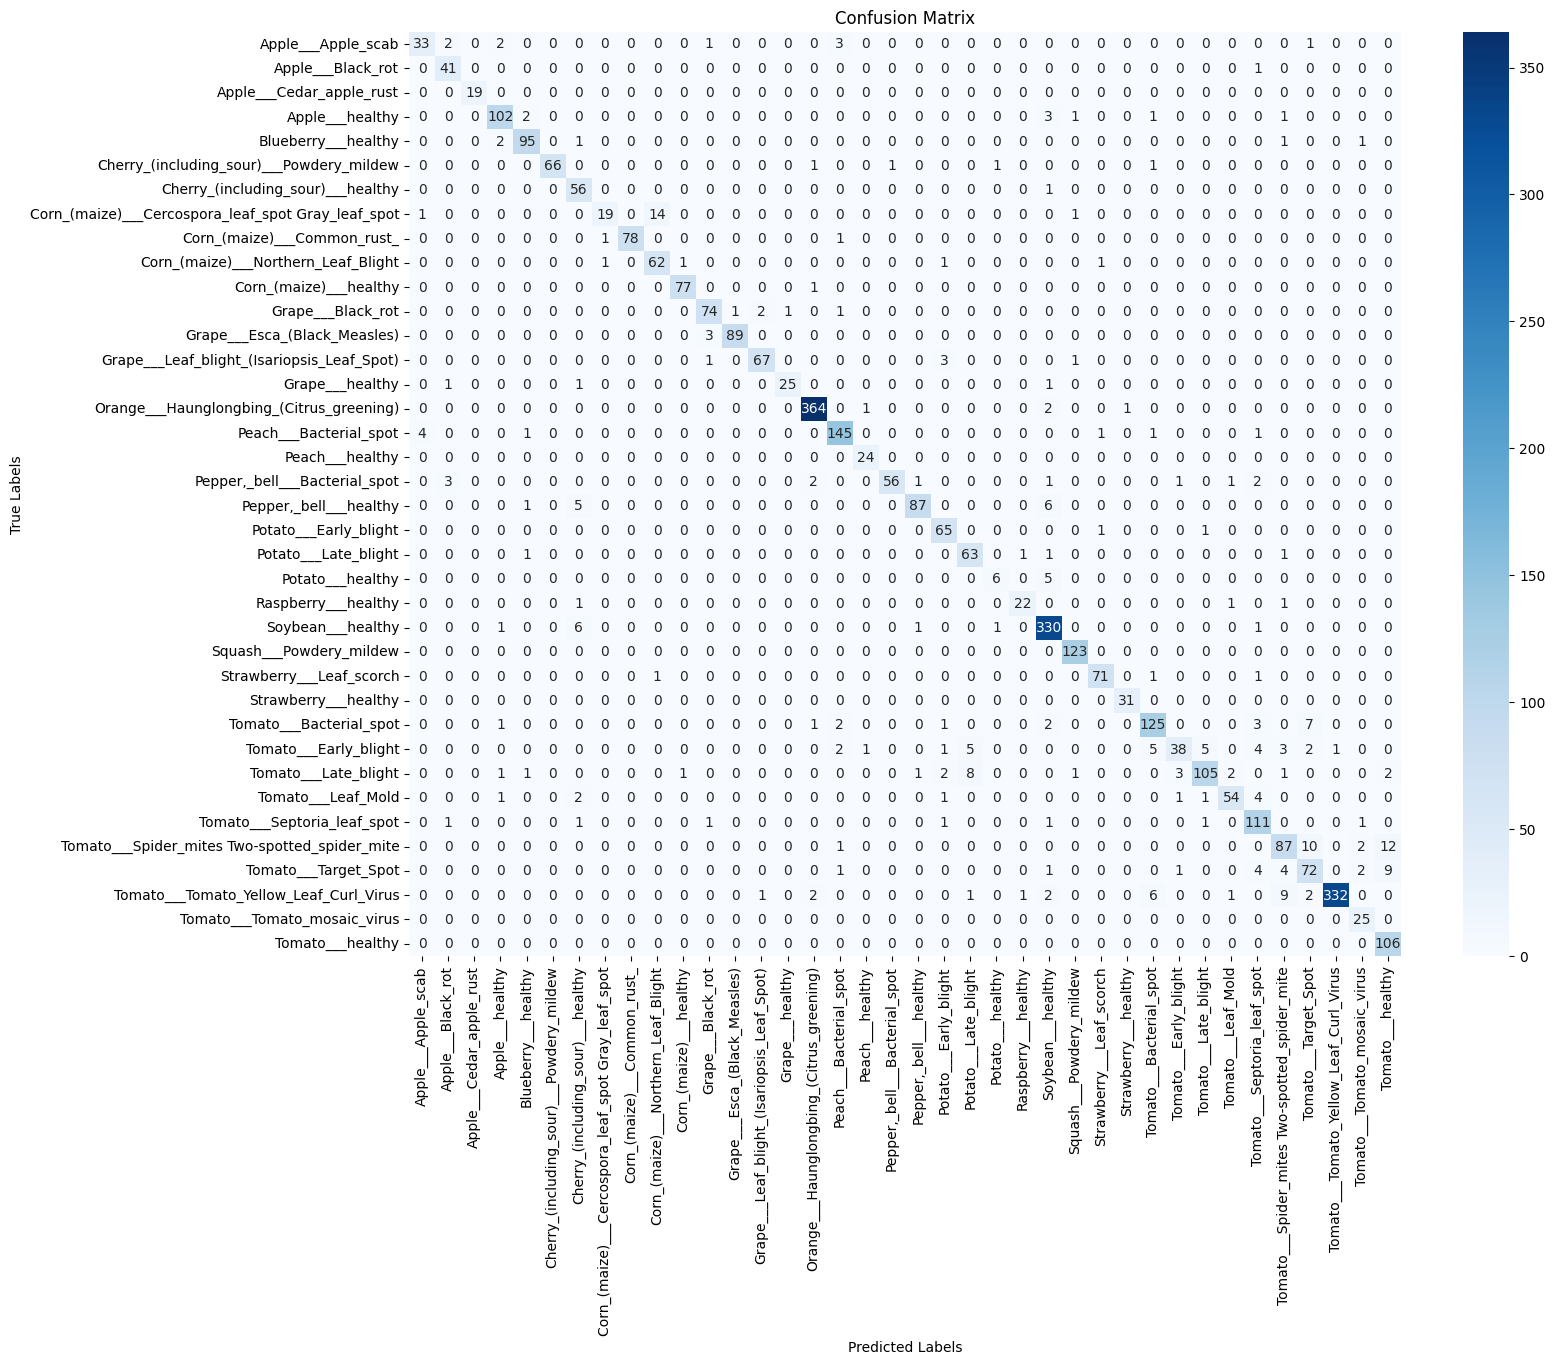

In [16]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_data.class_indices.keys(), yticklabels=test_data.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Model Prediction on a sample image

In [22]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Preprocess Input Data
def preprocess_input_image(image_path, img_size=(224, 224)):
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img)  # Convert image to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize the image
    return img_array

# Make Predictions
def make_prediction(image_path, model):
    preprocessed_image = preprocess_input_image(image_path)
    prediction = model.predict(preprocessed_image)
    return prediction

# Map Predictions to Class Names and Confidence
def map_prediction_to_class_name(prediction, class_indices):
    predicted_class_idx = np.argmax(prediction, axis=1)[0]  # Get the class index with highest probability
    class_names = list(class_indices.keys())
    predicted_class_name = class_names[predicted_class_idx]
    confidence = prediction[0][predicted_class_idx]  # Get the confidence score for the predicted class
    return predicted_class_name, confidence

# predicting a single image
image_path = '/content/apple_black_rot.JPG'
prediction = make_prediction(image_path, model)
predicted_class_name, confidence = map_prediction_to_class_name(prediction, train_data.class_indices)
print(f"Predicted Class: {predicted_class_name} with Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted Class: Apple___Black_rot with Confidence: 0.99


# Saving Class Labels

In [25]:
# Store Class Labels
class_labels_path = '/content/gdrive/MyDrive/class_labels.npy'
np.save(class_labels_path, train_data.class_indices)
print(f"Class labels saved at {class_labels_path}")

Class labels saved at /content/gdrive/MyDrive/class_labels.npy
